In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

In [0]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

In [0]:
def run_rf_experiment(X, y, feature_names, dataset_name):

    print("=" * 60)
    print(f"Dataset : {dataset_name}")
    print("=" * 60)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    baseline = RandomForestClassifier(random_state=42)
    baseline.fit(X_train, y_train)

    baseline_accuracy = accuracy_score(
        y_test,
        baseline.predict(X_test)
    )

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    tuned_accuracy = accuracy_score(
        y_test,
        best_model.predict(X_test)
    )

    print("Baseline Accuracy :", round(baseline_accuracy,4))
    print("Tuned Accuracy    :", round(tuned_accuracy,4))
    print("Best Parameters")
    print(grid.best_params_)

    return grid, best_model, baseline_accuracy, tuned_accuracy

In [0]:
iris = load_iris()

grid_iris, model_iris, base_iris, tuned_iris = run_rf_experiment(
    iris.data,
    iris.target,
    iris.feature_names,
    "Iris Dataset"
)

Dataset : Iris Dataset
Baseline Accuracy : 0.9
Tuned Accuracy    : 0.9667
Best Parameters
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}


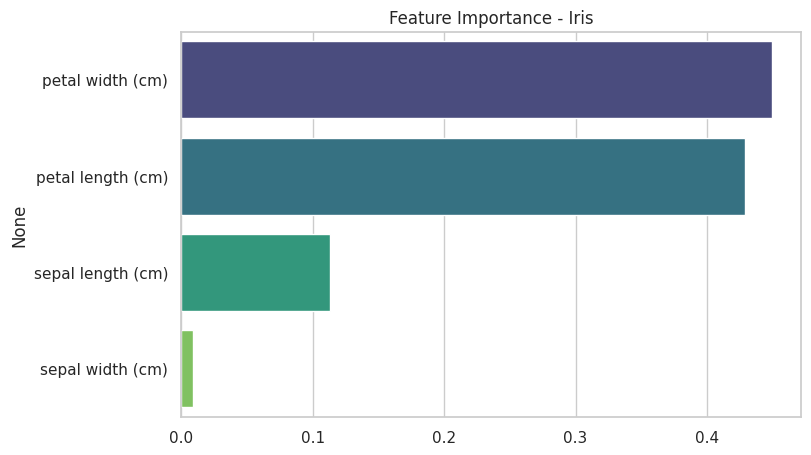

In [0]:
importance = pd.Series(
    model_iris.feature_importances_,
    index=iris.feature_names
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance.values,
    y=importance.index,
    hue=importance.index,
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Iris")

plt.show()

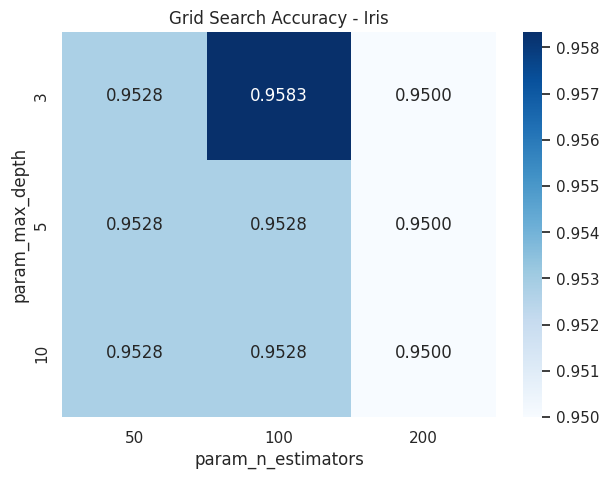

In [0]:
results = pd.DataFrame(grid_iris.cv_results_)

heatmap = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators",
    aggfunc="mean"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="Blues",
    fmt=".4f"
)

plt.title("Grid Search Accuracy - Iris")

plt.show()

In [0]:
cancer = load_breast_cancer()

grid_cancer, model_cancer, base_cancer, tuned_cancer = run_rf_experiment(
    cancer.data,
    cancer.target,
    cancer.feature_names,
    "Breast Cancer Dataset"
)

Dataset : Breast Cancer Dataset
Baseline Accuracy : 0.9561
Tuned Accuracy    : 0.9561
Best Parameters
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


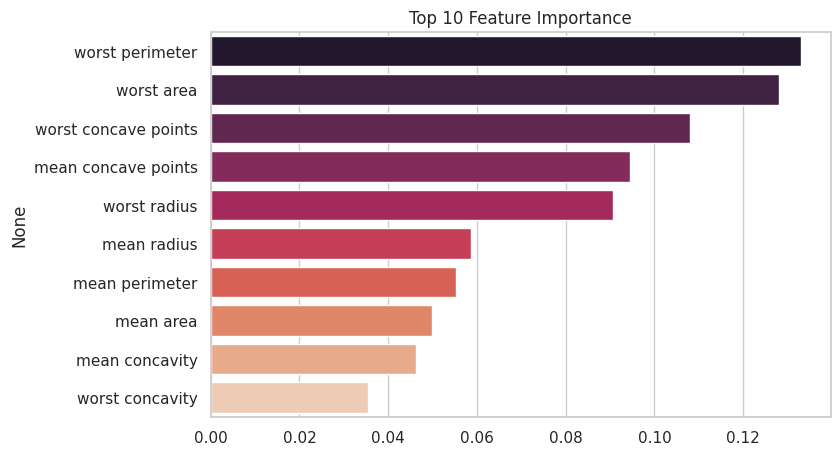

In [0]:
importance = pd.Series(
    model_cancer.feature_importances_,
    index=cancer.feature_names
)

importance = importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance.values,
    y=importance.index,
    hue=importance.index,
    palette="rocket",
    legend=False
)

plt.title("Top 10 Feature Importance")

plt.show()

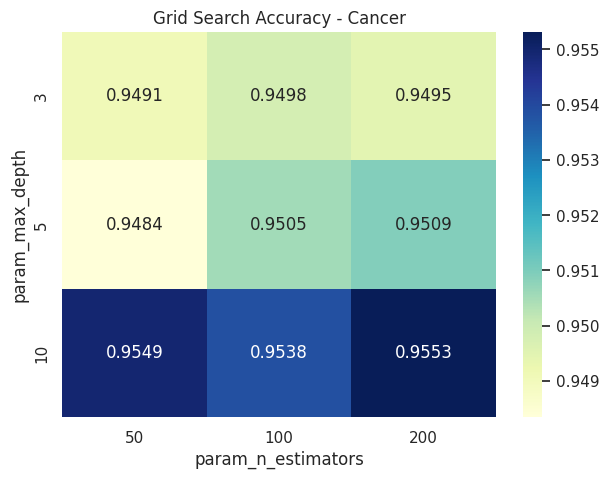

In [0]:
results = pd.DataFrame(grid_cancer.cv_results_)

heatmap = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators",
    aggfunc="mean"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title("Grid Search Accuracy - Cancer")

plt.show()

In [0]:
summary = pd.DataFrame({

    "Dataset":[
        "Iris",
        "Breast Cancer"
    ],

    "Baseline Accuracy":[
        base_iris,
        base_cancer
    ],

    "Tuned Accuracy":[
        tuned_iris,
        tuned_cancer
    ],

    "Best Parameters":[
        str(grid_iris.best_params_),
        str(grid_cancer.best_params_)
    ]

})

print(summary)

         Dataset  ...                                    Best Parameters
0           Iris  ...  {'max_depth': None, 'max_features': 'sqrt', 'm...
1  Breast Cancer  ...  {'max_depth': None, 'max_features': 'sqrt', 'm...

[2 rows x 4 columns]


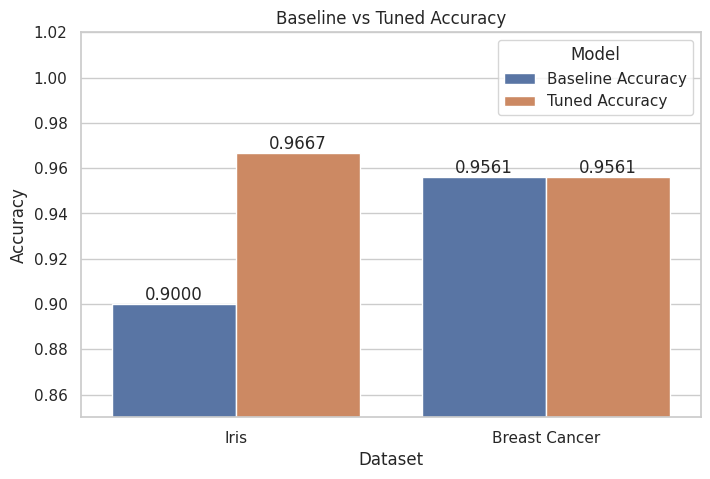

In [0]:
plot_df = summary.melt(
    id_vars="Dataset",
    value_vars=[
        "Baseline Accuracy",
        "Tuned Accuracy"
    ],
    var_name="Model",
    value_name="Accuracy"
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Accuracy",
    hue="Model"
)

for p in ax.patches:

    ax.annotate(

        f"{p.get_height():.4f}",

        (p.get_x()+p.get_width()/2,

        p.get_height()),

        ha="center",

        va="bottom"

    )

plt.ylim(0.85,1.02)

plt.title("Baseline vs Tuned Accuracy")

plt.show()